# Batch Score Analysis Report

This notebook provides an in-depth analysis of student scores across three different batches: **AI_ELITE_4**, **AI_ELITE_6**, and **AI_ELITE_7**. The analysis includes data cleaning, statistical summaries, and various visualizations to derive meaningful insights.

## 1. Setup and Data Loading

We will start by importing the necessary libraries and loading the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load the data
df = pd.read_csv('scores_data.csv')

In [4]:
# Display the first few rows
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


## 2. Data Cleaning

The `Score` column is currently in a string format (e.g., '6 / 7'). We need to extract the numeric score and clean the column names.

In [5]:
# Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

In [6]:
# Extract numeric score
df['Score'] = df['Score'].str.split('/').str[0].astype(float)

In [7]:
# Check for missing values
print('Missing values:\n',df.isnull().sum())

Missing values:
 Batch      0
User_ID    0
Score      0
dtype: int64


In [8]:
# Display cleaned data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Batch    149 non-null    object 
 1   User_ID  149 non-null    object 
 2   Score    149 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.6+ KB


In [9]:
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6.0
1,AI_ELITE_7,uid_148,6.0
2,AI_ELITE_7,uid_147,7.0
3,AI_ELITE_7,uid_146,7.0
4,AI_ELITE_7,uid_145,4.0


## 3. Statistical Insights (Non-Visualization)

Let's look at the descriptive statistics for each batch to understand the performance distribution.

In [10]:
df.describe()

,Score
count,149.000000
mean,4.382550
std,1.592199
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [11]:
# Group by Batch and calculate statistics
batch_stats = df.groupby('Batch')['Score'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])

In [12]:
batch_stats

,count,mean,median,std,min,max
Batch,,,,,,
AI_ELITE_4,48,3.791667,4.0,1.443376,0.0,7.0
AI_ELITE_6,48,4.229167,4.0,1.640441,0.0,7.0
AI_ELITE_7,53,5.056604,5.0,1.446682,2.0,7.0


In [13]:
# Calculate Mode separately as it's not a standard agg function
batch_mode = df.groupby('Batch')['Score'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
batch_stats['mode'] = batch_mode

In [14]:
# Display the statistics table
batch_stats.sort_values(by='mean', ascending=False)

,count,mean,median,std,min,max,mode
Batch,,,,,,,
AI_ELITE_7,53,5.056604,5.0,1.446682,2.0,7.0,6.0
AI_ELITE_6,48,4.229167,4.0,1.640441,0.0,7.0,5.0
AI_ELITE_4,48,3.791667,4.0,1.443376,0.0,7.0,4.0


## 4. Visualizations

### 4.1 Student Distribution per Batch

First, let's see how many students are in each batch.

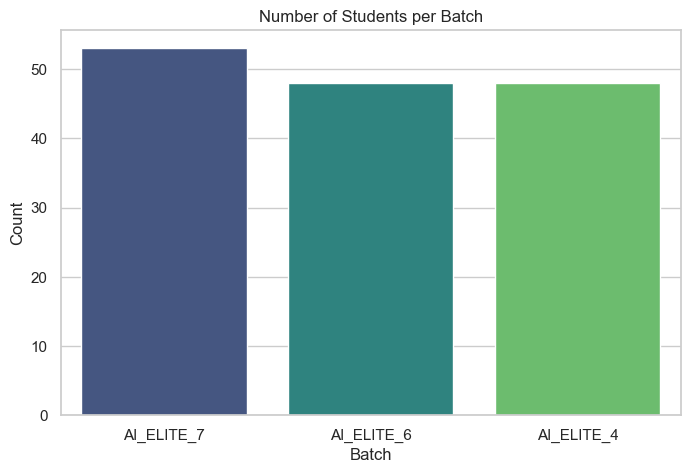

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Batch', palette='viridis')
plt.title('Number of Students per Batch')
plt.ylabel('Count')
plt.show()

### 4.2 Score Distribution and Spread

A box plot helps us visualize the median, quartiles, and potential outliers for each batch.

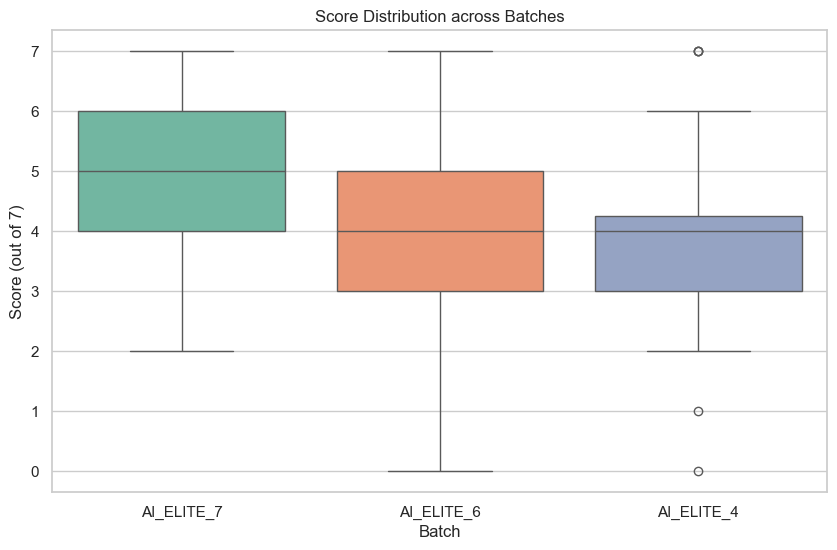

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Batch', y='Score', palette='Set2')
plt.title('Score Distribution across Batches')
plt.ylabel('Score (out of 7)')
plt.show()

### 4.3 Average Score Comparison

Comparing the mean scores to see which batch performed better on average.

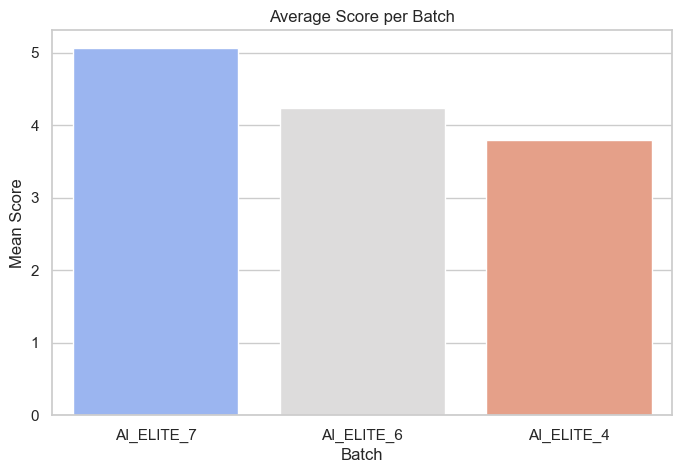

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Batch', y='Score', estimator=np.mean, palette='coolwarm', ci=None)
plt.title('Average Score per Batch')
plt.ylabel('Mean Score')
plt.show()

### 4.4 Score Frequency Distribution

Understanding the frequency of each score within the batches.

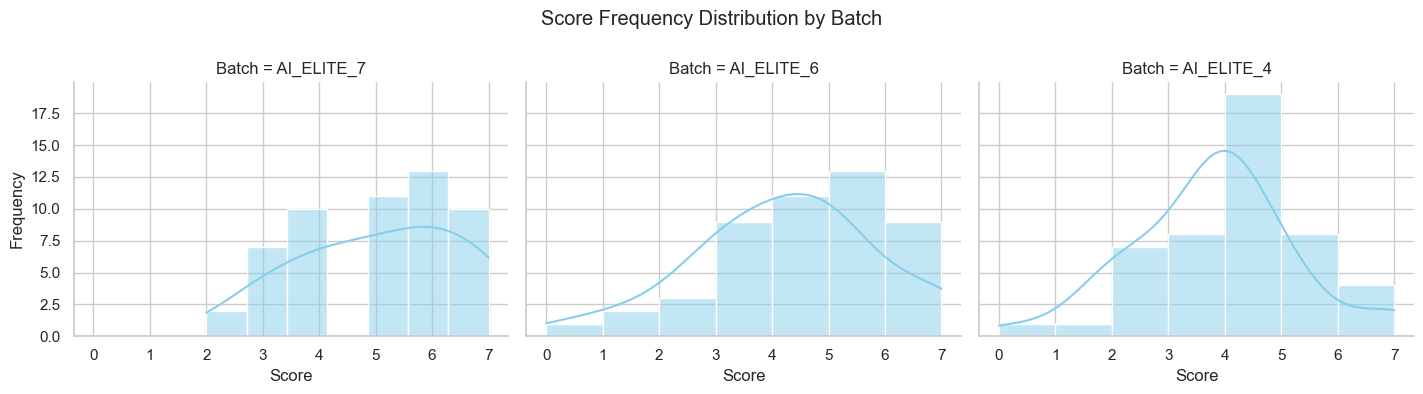

In [18]:
g = sns.FacetGrid(df, col='Batch', height=4, aspect=1.2)
g.map(sns.histplot, 'Score', bins=7, kde=True, color='skyblue')
g.set_axis_labels('Score', 'Frequency')
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Score Frequency Distribution by Batch')
plt.show()

## 5. Summary of Insights

Based on the analysis, here are the key takeaways:

1. **Batch Performance**: Compare the mean scores to identify the highest-performing batch.
2. **Consistency**: Look at the standard deviation; a lower value indicates more consistent performance among students.
3. **Participation**: The count of students shows the size of each batch.
4. **Score Trends**: The histograms reveal if the scores are skewed (e.g., most students scoring high or low).